# Chapter 4: Spatial Image Enhancement by Point Operations

In Chapter 3, we saw mathematical tools to process images. In this Chapter, we shall utilize these tools to enhance images.


In [ ]:
%%HTML
<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/-FqfaVkIORI" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p> <figcaption>Video 1: A nice introduction of Image Enhancement.</figcaption></figure>

**Motivating Question: What does image enhancement mean?**

In general, image enhancement refers to **accentuating some characteristics of image for a pre-defined goal.**

The goal of image enhancement depends on the application domain. For example, suppose that our goal is to enhance an x-ray image for the use of doctors to analyze the size and shape of a malignant tumors in the lung.

X-ray images consist of a lot of details that the doctors are not interested in to diagnose a specific disease, such as cancer. Image enhancement techniques enable us to emphasize the tumor in the lung, while suppressing the irrelevant details. Furthermore, we can detect the edges, which enable us to identify the type of the tumor.

# Popular Image Enhancement Methods

In the Image Processing literature, there are thousands of enhancement methods, each of which is designed for a specific goal in a specific application domain.

Let us briefly summarize some popular image enhancement methods that we shall study in this book:

- **Blurring and smoothing,** reduces the sudden color changes in the image by making the color transitions of the image relatively smoother compared to the original one. This technique is used to remove the various types of noise and undesired details.  For example, in a satellite imagery, our goal may be to discriminate the sea from the land. In this problem, the irrelevant texture introduced by the forests or urban areas can be blurred prior to design a robust segmentation algorithms, which partitions the image into sea and land regions.
 

- **Contrast stretching,** increases the color contrast to make the image look better with respect to our visual system. For example, if we take a photo of an outdoor scene in a cloudy day, most of the colors are squished in dark color ranges. Contrast stretching allows us to stretch some of the colors to make the image look brighter.

- **Edge detection,** finds the abrupt color or intensity  changes. The sudden color changes in the image mostly corresponds to the object boundary. Therefore, edge detection is a preliminary crucial step to detect the object boundary and shape. For example, if we need to count the specific  cells, with a predefined size in a microscopic image, first we detect the edges. Then, we form a closed boundary of each cell. Finally, we compute the size by counting the number of edge pixels lying on a boundary. 

The above image enhancement methods can be grouped under two major categories: 


1. Spatial Domain Methods
2. Transform Domain Methods.

In Chapter 4 and 5, we study popular spatial domain methods. In Chapter 6 and 7, we introduce new domains, called, transform domains, to enhance images.

# Image Enhancement in Spatial Domain

Spatial Domain methods enhance images by changing the pixel brightness values using a series of linear or nonlinear operations, in space domain. These techniques can be studied in two groups:

1)  **Point Operations**, which changes the color palette of an image independent of the position of a pixel.

2)  **Spatial Filtering**, which changes the brightness value of a pixel, depending on its position.

In this chapter, we study the point operations  for image enhancement.

## 1. Point Operations

Point operations change the color $r$ in the palette original color  to color $s$, by a mapping $T$,

$$s = T(r).$$

  

As a result, the color or brightness value of an original image, $f(x,y)=r$, are changed to obtain the desired image, $g(x,y) = s$, after the mapping by $T$.

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-1.drawio.png" height=300px><figcaption> Figure 1: Point operations: Each color, $r$, in the original image, $f(x,y)$, is mapped to  color,  $s = T(r)$, in the enhanced image. This nonlinear mapping makes the dark colors darker and stretches the light colors. Note that **$T$ must be a monotonically increasing function of $r_k$**. Otherwise, at the output image, multiple gray values are assigned to the same value of the original image. This may results in generating more then one image with different context.</figcaption></p></figure>

  

There is a large variety of point operations, which determines the transform function, $T$, implicitly or explicitly for enhancing the color content of images. Intensity transform techniques can be grouped under three heading:

1. Gray scale or color transforms

2. Bit plane slicing

3. Histogram processing


### 1. Gray Scale or Color Transforms
In some applications, we may have information about the characteristics of an image acquisition device or the image capturing environment. In these circumstances, we may directly define the transformation function, $T$. For example; in cloudy weather, we know that the illumination conditions are poor and we may want to get bright images or vice versa, on a sunny day, we may want to suppress the high illumination.

  

**Motivating Question:** How do we make an image darker or brighter by using gray scale or color transform?

  

Define a linear transformation $s=m.r$, where r is the color in the original image and $s$ is the transformed color in the output image. For $m \lt 1$ image gets darker for $m \gt 1$ image gets brighter..

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-2.drawio.png" height=300px><figcaption> Figure 2: The linear mapping $s = m.r$, makes the image darker if $m \lt 1$ and makes the image lighter if $m \gt 1$. If $m = 1$, there is no change in the image. </figcaption></p></figure>

  
  

**Q:** How do we binarize a gray scale or color image for extracting the shapes of the objects?

  

Define a nonlinear transform, called thresholding,

  

$s=\begin{cases} T(r) & \text{for } r\lt m \\ 0 & \text{otherwise}\end{cases}$.

  
  
  

**Note:** Selection of the threshold $m$ is a critical design issue.

  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-3.drawio.png" height=200px><figcaption> Figure 3: The thresholding transform, $T$, (left) assigns the dark colors to black and all the light colors to white, resulting in increased contrast of the image. The transform $T$ in the right, binarize the image. </figcaption></p></figure>

  
  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i3_tolu.png" height=200px><figcaption> Figure 4: The blurry image in the left is binarized by the intensity transform function of Figure 3 (right).</figcaption></p></figure>

  

**Q:** What is the intensity transform function to negate (reverse the dark colors by light colors) an image?

  

If we define $s= -r,$ this function negates the image (see figure 5).

  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i4_tolu.png" height=300px><figcaption> Figure 5: Intensity transform $s=T(r)=-r$ to negate image in the left.</figcaption></p></figure>

  
  

**Q:** Suppose we have a dark image given below (left), how do we increase the contrast of this image to obtain the image on the right?

  
  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i5_tolu.png" height=400px><figcaption> Figure 6: Left: The window is poorly illuminated. Right: Enhanced image. </figcaption></p></figure>

  
  

The required transformation, $s=T(r)$, is as follows:

  
  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-6-c.drawio.png" height=300px><figcaption> </figcaption></p></figure>

  
  

**Q:** What happens to an image when you apply following transform, called **power law transform**?

$$s = cr^{\gamma}.$$

  

Power law transforms changes the contrast of the image depending on the selection of parameters $c$ and $\gamma$. Note that when $c=1$ and $\gamma =1,\quad$ then, $s=r$,which results in no change in the image.

  

For $c=1$ and $\gamma \gt1\quad$ the image gets darker whereas for $\quad \gamma \lt 1$, the image gets brighter.

  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/image6.png" height=300px><figcaption>Figure 7: Power law transform, $s = cr^{\gamma}$ for $c=1$. </figcaption></p></figure>

  

Selection of the parameters $c$ and $\gamma$ is a design issue, which requires preliminary information about the image dataset and the goal of the image processing algorithm.

  
  
  
  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i7.png" height=300px><figcaption>Figure 8: Effect of $\gamma$ on power law transform of image: MR image of a knee (upper left). Power law transform, $s = cr^{\gamma}$ for $\gamma= 0.6, 0.4, 0.3$, for upper right, down left and down right images respectively. $c=1$, in all images.  </figcaption></p></figure>


  
  



**Programming exercises:**

1.   Run the following code to see the output of binarizing the grayscale image.
2.   Change threshold values to 30, 100, and 200 and run the code. See how the output changes.


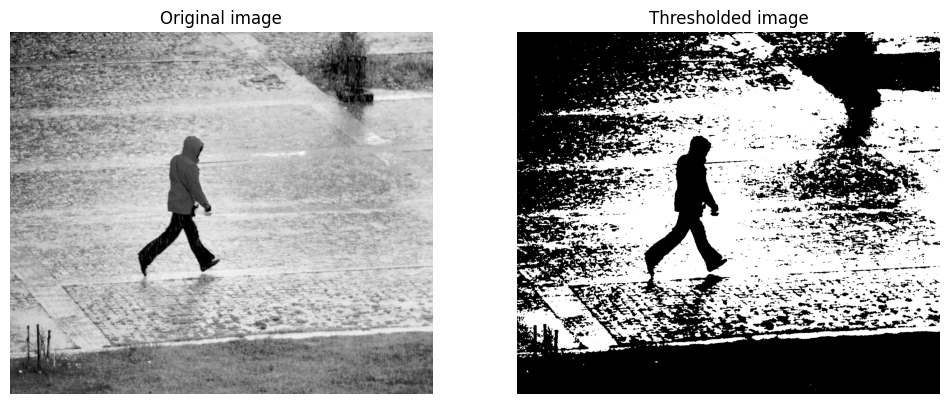

In [1]:
# Binarize a grayscale image 
import matplotlib.pyplot as plt
from skimage import data, color, io

thresh = 200
image = data.camera()
################ EDITED PART #############
thresh = 150
# Load image
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/yeni.png
image = io.imread('yeni.png')
##########################################
binary = image > thresh

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(binary, cmap=plt.cm.gray)
ax[1].set_title('Thresholded image')
ax[1].axis('off')

plt.show()



**Programming exercises:**

1.   Run the following code to see the output of binarizing the grayscale image.
2.   Change dark_coefficient to 0.25 run the code. See how the output changes.
3.   Change bright_coefficient to 1.8 run the code. See how the output changes.

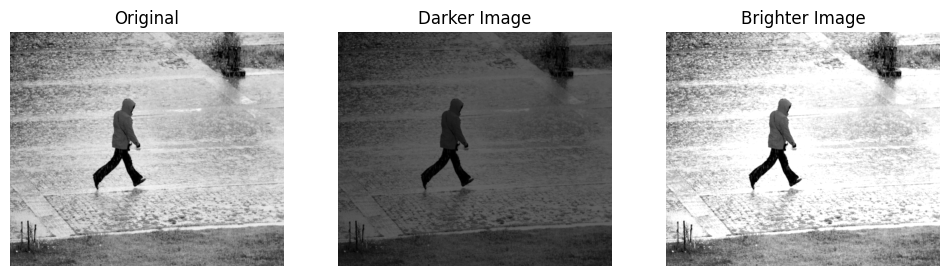

In [2]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5))
ax = axes.ravel()
dark_coefficient = 0.5
bright_coefficient = 1.5
image = data.camera()
################ EDITED PART #######################
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/yeni.png
image = io.imread('yeni.png')
###################################################
ax[0].imshow(image, cmap=plt.cm.gray, vmin=image.min(), vmax=image.max())
ax[0].set_title('Original')
ax[0].axis('off')

darker_image = image * dark_coefficient
ax[1].imshow(darker_image, cmap=plt.cm.gray, vmin=0, vmax=255)
ax[1].set_title('Darker Image')
ax[1].axis('off')

brighter_image = image * bright_coefficient
brighter_image[brighter_image > 255] = 255
ax[2].imshow(brighter_image, cmap=plt.cm.gray, vmin=0, vmax=255)
ax[2].set_title('Brighter Image')
ax[2].axis('off')

plt.show()

**Programming exercises:**

1.   Run the following code to see the output of inverting an image.

(-0.5, 3623.5, 3102.5, -0.5)

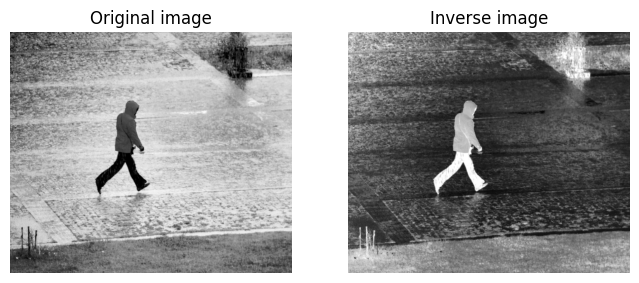

In [3]:
from skimage.util import invert

image = data.camera()
################ EDITED PART #######################
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/yeni.png
image = io.imread('yeni.png')
###################################################
inverse_image = invert(image)

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(inverse_image, cmap='gray')
ax[1].set_title('Inverse image')
ax[1].axis('off')



**Programming exercises:**

1.   Run the following code to see the output of applying power-law transform.
2.   Change low_gamma to 0.25 run the code. See how the output changes.
3.   Change high_gamma to 2.5 run the code. See how the output changes.

(-0.5, 3023.5, 4031.5, -0.5)

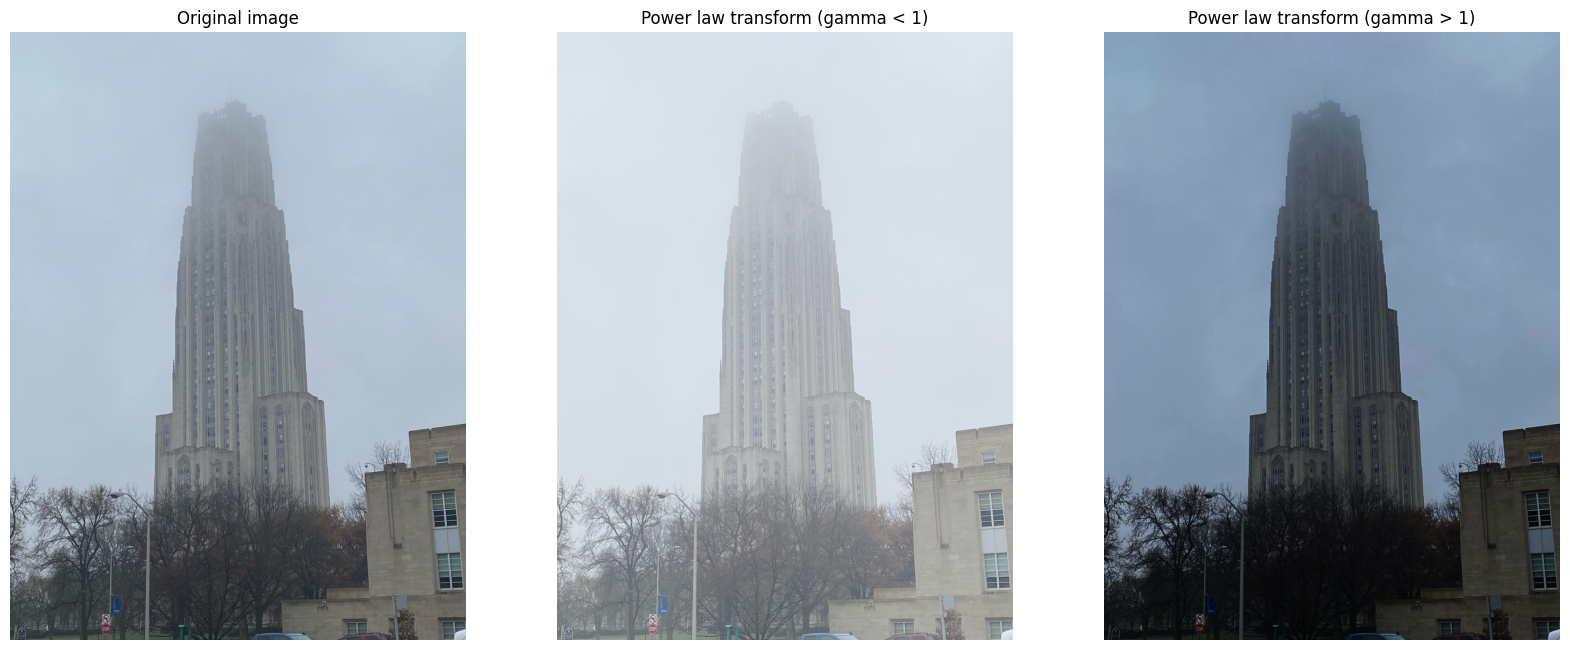

In [4]:
## Power-law transform

import matplotlib.pyplot as plt
from skimage import data

c = 1
low_gamma = 0.5
high_gamma = 2

#img = data.moon()
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/cathedral.jpg
img = io.imread('cathedral.jpg')
# Convert the image to float and scale it to [0,1]
img = img.astype(float)
img = (img-img.min())/img.max()

img_low_gamma = c*img**low_gamma;
img_high_gamma = c*img**high_gamma;

fig, axes = plt.subplots(ncols=3, figsize=(20, 10))
ax = axes.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(img_low_gamma, cmap='gray')
ax[1].set_title('Power law transform (gamma < 1)')
ax[1].axis('off')

ax[2].imshow(img_high_gamma, cmap='gray')
ax[2].set_title('Power law transform (gamma > 1)')
ax[2].axis('off')


### 2. Bit Plane Slicing:
Suppose each pixel of an image is represented by $k$ bits. We can represent each bit of the pixel brightness value by a binary number. Then, the image can be represented by k-binary images. For example; if an image has 256 colors, each pixel is represented by an integer value $r\in [0-255]$. This representation requires 8 bits/ pixel, which corresponds to 8 binary images, as shown in Figure 7.

  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i8_tolu.png" height=200px><figcaption>Figure 9: Bit plane representation of an 8 bits/pixel image. A gray level image is then represented by 8 binary images.</figcaption></p></figure>

**Q:** What is the use of bit plane representation?

  

In bit plane representation, the leftmost bit, called the most significant bit, shows the most significant visual information. As we move down to the least significant bit, the visual information diminishes (see; Figure 8). Therefore, this representation enables us to decompose an image into coarse-to-fine components.

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i9_tolu.png" height=500px><figcaption>Figure 10: The starry night of Vincent Van Gogh  and its bit plane representations, as 8 binary images. The most significant bit (Bit-plane 7) has the most important visual information. The least significant bit is almost like a spherical noise.</figcaption></p></figure>


**Ex:** Consider a 2- bit/pixel gray level image given below. Find its bit plane representation.

  
  

| 0 | 1 |
|---|---|
| 2 | 3 |

Click button for answer

  

There are four colors in this image, represented in base-10 and base-2, as follows;

Black: $(0)_{10}$ =$(00)_{2}$

Dark gray: $(1)_{10}$ = $(01)_{2}$

Gray: $(1)_{10}$ = $(10)_{2}$

White:$(3)_{10}$= $(11)_{2}$

  

We form the most significant bit plane by taking the leftmost values of base-2 representation at each pixel location. The least significant bit plane is formed by taking the rightmost values of base-2 representation at pixel locations. Therefore, we represent this image by 2 binary images, as shown in Figure 11.

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/L4_f11.png" height=300px><figcaption>Figure 11: Bit plane representation of a 2-bit/pixel gray level image. Original image in the left is represented by two binary images in the right. The most significant bit plane shows a horizontal stripe, and least significant plane  shows a vertical stripe.</figcaption></p></figure>

### 3. Histogram Processing

Given an image of $L$ gray values, color histogram represents the relative frequency of colors.

**Definition: Color histogram** of an image is defined as,

$$h(r_k) = n_k,$$

Where $n_k$ is the number of pixels with value $r_k.$

**Note:** For grey level images, we define only one color histogram. For color or multispectral images, we need to define a color histogram for each band.

**Definition: Normalized color histogram** for $n=N\times M$ image is defined as,

$$p(r_k) = \frac{n_k}{n}.$$

**Note**: Normalized color histogram approximates probability mass function, $p(r_k)$.

**Definition: Cumulative color histogram** is defined as

$$h_c(r_k) = \displaystyle\sum_{r_j = 0}^{r_k}h(r_j)$$

**Definition: Normalized cumulative color histogram** is defined as

  

$$P(r_k) = \displaystyle\sum_{r_j = 0}^{r_k}p(r_j)$$

**Note:** Normalized cumulative histogram approximates probability distribution function, $P(r)$.

  

**Fact:** We can employ probabilistic operations to the images using the color histograms, where color $r_k$ can be considered as a discrete random variable with its associated probability mass function $p(r_k)$, which is approximated by normalized color histogram.

  
  
  
  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i10_tolu_c.png" height=600px><figcaption>Figure 12: Histograms of various grey level images. Compare the histograms of these images. What do you observe?</figcaption></p></figure>

  

**Fact:** Color histogram gives us a general idea about the color content of an image. For example; histogram of a dark image consists of high frequency components for dark colors. Histogram of a low contrast image has only mid values , the rest of the grey values has 0 relative frequencies. A High contrast image has an almost **flat histogram**, consisting of all color values.



In [5]:
%%HTML
<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/2LhfSgrjdGo" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p><figcaption>
Video 2: Image Histograms.</figcaption></figure>

#### 3.1. Histogram Equalization

**Q:** Is it possible to enhance an image by changing its color histogram in a controlled way?

The answer lies in the technique called **histogram equalization**. When we have a low contrast image, histogram equalization technique finds a transformation $s_k = T(r_k)$, which increases the contrast.

A high contrast image has a relatively flat histogram, compared to that of a low contrast image, as observed from Figure 13. Therefore, if we find a transformation, $T$, which **flattens the histogram** of the original image, then, this transformation increases the contrast of the image.

Mathematically speaking, we are seeking a transformation $T: r_k \rightarrow s_k$, such that the histogram of the desired image, $g(s_k)$ has a uniform histogram, i.e.,

$$g(s_k) = \frac{NM}{L-1} , \quad s_k = 0 , ... , L-1,$$

where $L$ is the number of colors and $NM$ is the size of the image.
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-13-alternative.drawio.png" height=200px><figcaption>Figure 13: Left: a poor contrast original image, with histogram $h(r_k)$. Right: High contrast desired image with histogram $g(s_k)$. </figcaption></p></figure>

  

Recall the definition of **Cumulative Histogram:**

$$ h_c(r_k) = \sum_{r_j = 0}^{r_k}h(r_j).$$

  

This function is a [monotonically increasing](https://en.wikipedia.org/wiki/Monotonic_function) function of $r_j$. Thus, it is easy to find the transformation $T$, by equating the cumulative histograms of the original and desired images. In other words,

  
  

$$\displaystyle\sum_{s_i = 0}^{s_k}g(s_i) = \displaystyle\sum_{r_i=1}^{r_k}h(r_i).$$

  

Since we require a uniform histogram for the desired image, we replace the left hand side of the equation by the uniform function as follows,

  

$$\displaystyle\sum_{s_i = 0}^{s_k}g(s_i) = \ s_k \frac{NM}{L-1}= \displaystyle\sum_{r_i=0}^{r_k}h(r_i).$$

  

Leaving the color $s_k$ alone in the left hand side, we get,

  

$$s_k = \frac{L-1}{NM} h_c(r_k).$$

The above equation provides the transformation $s_k = T(r_k)$ to change the histogram of the original image to the flat histogram of the desired image. However, there is a problem: The colors of the desired histogram may not be integers, due to the division, $\frac{L-1}{NM}.$

Thus, we make a slight modification in the above transformation,

$$\boxed{s_k = round[\frac{L-1}{NM} h_c(r_k)]},$$

where $h_c(r_k) = \sum h(r_i)$ is the cumulative histogram.

The old colors $r_k$ of the original image are replaced by the transformed colors $s_k= T(r_k)$ to obtain the equalized image.

  



>**Algorithm: Histogram Equalization** 
>>1. Create an array $h$ with $L$ gray values. Initialize with 0 value
>>
>>2. Find the histogram $h(r_k) = h(r_k)+1$
>>
>>3. Find cumulative histogram $h_c(r_k) = h_c(r_{k-1})+h_c(r_k)$
>>
>>4. Set $T(r_k)=round(\frac{L-1}{NM}h_c(r_k)) = s_k$
>>
>>5. Create equalized image with the new color palatte, $s_k=T(r_k)$



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i12_tolu_c.png" height=200px><figcaption>Figure 14: A poor contrast image (left). Equalized image (right). </figcaption></p></figure>

  

**Ex:** If you could plot the histograms of the original image and equalized image of Figure 14, what would you observe as difference?

  

Click the button to see the answer:

  

The histogram of the original image would have high frequency components at the mid values. The histogram of the equalized image has a flatter histogram compared to the original one.

  

Ex: Consider a hypothetical 3 bits/pixel image and its color histogram, given in Figure 15:

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/im1_wh.png" height=300px><figcaption>Figure 15: A 3x2 hypothetical image (left), its histogram $h(r_k)$ (right).</figcaption></p></figure>

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/2.png" height=300px><figcaption>Figure 16: Cumulative histogram, $h_c(r_k)$ of the image given in Figure 15.</figcaption></p></figure>

  
  

Histogram equalization yields the following transformation equation, for $L-1=7$ and $NM=6$ pixels:

  

$s_k = round(\frac{7}{6} h_c(r_k))$

  

According to the above equation, for each color of the original image, $r_k= 0, 1, 2, ….,7$, we obtain a new color $s_k$, for the desired image, as follows,

$s_0 = s_1 = 0,$

$s_2 = 1,$

$s_3 = 3,$

$s_4=s_5=s_6=s_7=7.$

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4_new.png.svg" height=300px><figcaption>Figure 17: Plot of the transformation $T$, obtained by histogram equalization.</figcaption></p></figure>

  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/im1eq_wh.png" height=300px><figcaption>Figure 18: Equalized image and equalized Histogram of the 3x2 image of this example.</figcaption></p></figure>

  

**Q:** In the above example, the formulation is expected to generate a flat histogram, after the histogram equalization. Although we get a flatter histogram for the desired image, it is not an ideally uniform function. Why?

  

Rounding operation violates the equality of

$$s_k = \frac{L-1}{NM} h_c(r_k).$$

  

Thus we do not exactly satisfy the above equality.

  

If we had a large size image (such, 1024x1024 image) with many grey values (such as, 512 gray values), we could get a flatter histogram. As we increase the spatial and radiometric resolution, we get closer to a continuous image. In the limit, where we have a continuous image, we replace the sum operations with integration operations and we converge to a flat probability density function, at the output of the equalization process.

  

**Q:** What if we apply histogram equalization to a high contrast image?

  

Surprisingly, histogram equalization technique does not always provide the desired result :smile:.

For example consider the high contrast image given in Figure 19. Obviously, the histogram of this image consists of high relative frequencies at dark and bright colors. It has practically no pixels in the mid range colors. When we try to equalize the histogram, the desired image has a flatter histogram with mid range colors, spoiling the quality of the image content.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i13_tolu_c.png" height=200px><figcaption>Figure 19: A High contrast image (left) and the result of histogram equalization (right). The equalized histogram has many mid range grey values.</figcaption></p></figure>



**Programming exercises:**

1.   Run the following code to see the output of histogram equalization.

Text(0.5, 1.0, 'Histogram After Equalization')

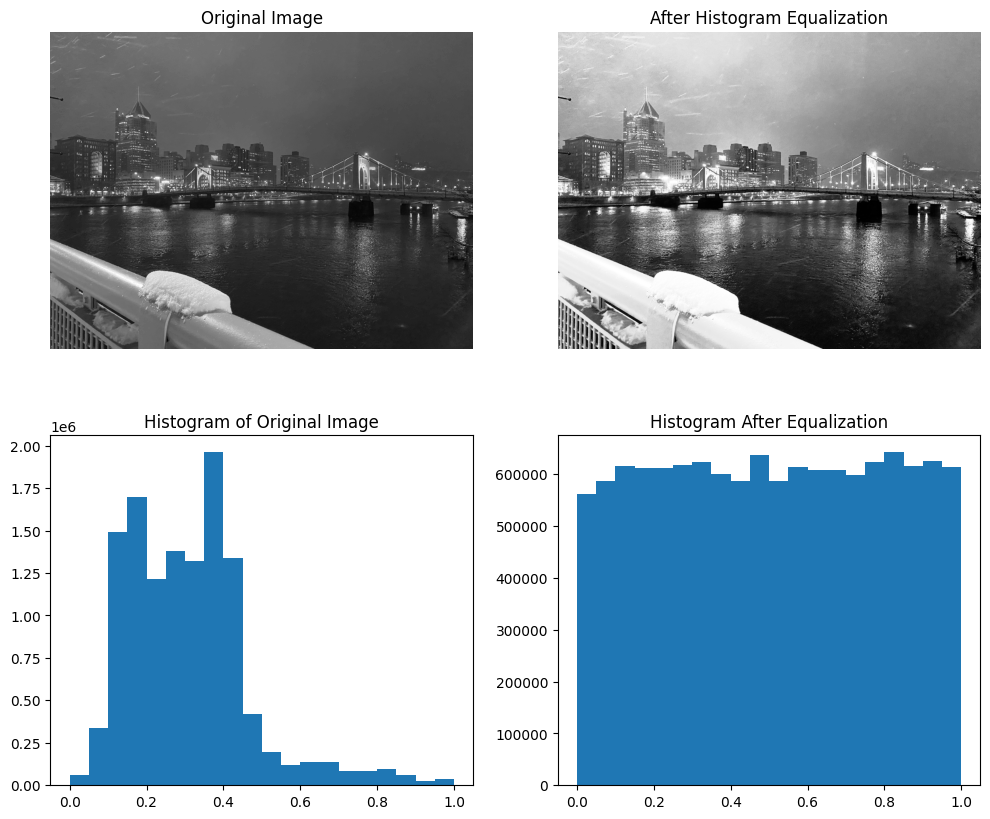

In [6]:
#Histogram equalization
import matplotlib.pyplot as plt
from skimage import data
from skimage import exposure

#img = data.moon()
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/pitt.jpg
img = color.rgb2gray(io.imread('pitt.jpg'))
img_hist_eq = exposure.equalize_hist(img)

plt.figure(figsize=(12,10))
plt.subplot(221), 
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(222), 
plt.imshow(img_hist_eq,cmap='gray')
plt.title('After Histogram Equalization')
plt.axis('off')
plt.subplot(223), 
plt.hist(img.ravel(),bins=20)
plt.title('Histogram of Original Image')
plt.subplot(224), 
plt.hist(img_hist_eq.ravel(),bins=20)
plt.title('Histogram After Equalization')


In [7]:
%%HTML
  

<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/WuVyG4pg9xQ" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p><figcaption>
Video 2: Histogram equalization of poor contrast images.</figcaption></figure>

#### 3.2. Histogram Specification
Applying histogram equalization does not always provide the desired image for many reasons:

1. While stretching the contrast by histogram equalization, we may lose some colors which may carry important information about the image.

2. If a high contrast image has some undesired colors, we cannot remove them by histogram equalization.

3. If an image has high contrast in some parts and low contrast in some other parts, histogram equalization spoils the high contrast regions.

  

An alternative technique to histogram equalization, is a technique, called **histogram specification**. This technique can handle some of the problems mentioned above, if a priori information about the histogram of the desired image is available. Then, we may find a transformation, $T$, which maps the color palette of the original image to that of the desired palette, such that the histogram of the original image is transformed to the histogram of the desired image.

  

Consider an image with heavy shadow and its histogram given in Figure 20.a. If we equalize the histogram of this image the contrast of the image is decreased (Figure 20.b). Equalization  results in pale image.

  
  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i14_new_tolu_2.png" height=600px><figcaption>

Figure 20: a) An outdoor image under heavy shadow, b) The histogram image the image in a). c) Equalized image d) The histogram of the equalized image. e) The transformation function, $z_k = T(r_k)$, which maps the original image into the equalized image.  </figcaption></p></figure>

  

In this image the contrast in the bright side is quite high whereas the contrast under the shadow is very low. Thus, we can specify the histogram of the desired image to improve the contrast of the regions under shadow, as shown in Figure 21-left, where the specified histogram moves  dark colors to relatively less dark colors, while keeping the bright values, the same as before.

  
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/i16_new_tolu.png" height=300px><figcaption>

Figure 21: Specified Histogram, $z_k = T(r_k),$ (left) and the output image after histogram specification (right). Notice that the specified histogram stretches the dark colors in the shadow regions and keep the bright colors.</figcaption></p></figure>

  
  

Mathematically speaking, given an original image with its histogram $h(r_k)$, our goal is to find a transform $T,$

$$z_k = T(r_k),$$

so that the desired image has the specified histogram, $g_d(z_k)$ and $z_k, \forall k$ is the colors in the palette of the desired image.

  

**Q:** How do we find a transformation $T$ to map the histogram of the original image to the histogram of the desired image?

  

All we need to do is to use histogram equalization. In other words, we perform two histogram equalizations:

1. We equalize the histogram of the original image

2. We equalize the histogram of the desired image

  

3. Then, we equate the two equalized histograms to obtain the transformation $T$.

  
  

Lets formalize the above steps: Suppose that the histogram of the original image $h(r_k)$ and that of the desired image, $g_d(z_k)$ are both equalized to a flat histogram, $g(s_k)$ as shown in Figure 22. These equalizations yield two mappings, $T_1$ and $T_2$, as follows;

  

$$s_k = T_1(r_k) = round [\frac{L-1}{NM}h_c(r_k)]$$

and

$$s_k = T_2(z_k) = round [\frac{L-1}{NM}g_{d,c}(z_k)],$$

  

where $h_c(r_k)$ and $g_{d,c}(z_k),$ are the cumulative histograms of the original and desired images. If we equate the above equations, we get,

$$T_1(r_k) = T_2(z_k).$$

  
  

Recall that our goal was to find a transformation,

  

$$T : r_k \rightarrow z_k.$$

Thus, the color values of the specified histogram, $z_k$ can be obtained from the following equation;

  

$$\boxed{z_k = T_2^{-1} (T_1(r_k)) = T(r_k)},$$

  

where $T_2^{-1}$ is the inverse of $T_2$.

  

Once we have the transformation $T$, we can get the desired specified histogram and the corresponding specified image.

  <figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/4-22.drawio.png" height=300px><figcaption>Figure 22: Histogram specification is achieved by two histogram equalization schemas. </figcaption></p></figure>



**Algorithm: Histogram Specification**

1. Equalize the histogram of the original image and obtain the transformation $T_1$ from the following equation,

$s_k = T_1(r_k) = round(\frac{L-1}{NM}h_c(r_k))$.

2. Equalize the histogram of the desired image and obtain the transformation $T_2$ from the following equation,

$s_k = T_2(r_k) = round(\frac{L-1}{NM}g_d(z_k))$

3. Obtain the colors of the desired image from $z_k = T_2^{-1} (T_1(r_k))$ for specified histogram.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W4/image15_tolu.png" height=250px><figcaption>Figure 23: Schematic representation of histogram specification: We obtain two transformations by equalizing the original and specified histograms, $T_1$ and $T_2$, respectively. Note that the equalized histograms have the same color palette, $s_k$. Then, the colors of the specified histogram is obtain from $z_k = T_2^{-1} (T_1(r_k)).$ </figcaption></p></figure> 

  
Note that the transformation functions, $T_1$ and $T_2$, are obtained by equating the **monotonically increasing cumulative distribution functions** of the original and desired histograms. Therefore, $T_1$ and $ T_2$ are **one-to-one and onto**, meaning that there is a unique inverse for both of them.

**Q:** How do we find inverse of a function, $T^{-1}$, from $T$?
 
 Finding the inverse of a general function may not be easy or possible at all. However, in our case the transformation function $T_2$ approximates the cumulative histogram. Thus, it is a monotonically increasing function. In order to  find the inverse of the transformation function we replace the domain and range as follows;

$$T: s_k \rightarrow z_k$$

$$T^{-1} : z_k \rightarrow s_k$$

  





#### 3.3. Histogram Statistics

  

We mentioned that the  normalized color histogram  of an $N\times M$ image approximates the probability density function of the random variable $r_k$, is defined  as follows;

  

$$p(r_k) \approx \frac{1}{N\times M} h(r_k).$$

Therefore, for a given image, we can define  the statistics about the random variable, $r_k$, such as mean, variance and central moments, as follows:

Mean Value of a k bits/ pixel image  with $2^k = L$ colors is defined as,

$$\mu = \sum_{k=0}^{L-1} r_k p(r_k).$$ 

Mean value shows the average color of an image


The variance,

$$\sigma^2 = \sum_{k=0}^{L-1}  (r_k-\mu)^2 p(r_k)$$ 

shows the variations of colors in an image. The $n$th Central Moment,

$$\mu_n(r_k) = \sum_{k=0}^{L-1}  (r_k-\mu)^n p(r_k)$$ 

shows the higher degree color variations on an image.

**Motivating Question:** Where do we employ histogram statistics?

Histogram statistics provide information about the color content of an image. For example; color means $\mu$ tells us the average color of the image, whereas the variances show how colorful an image is. If we need to change the average color of the image, we shift the histogram to change the color mean. If we need to change the colorfulness of the image, we stretch or squish the histogram. With this method, we can increase and decrease the number of colors in the image.

# Chapter Conclusion

We started this chapter by introducing the general definition of image enhancement. We categorized the image enhancement methods under two major headings, namely, spatial and frequency domain methods. We also mentioned that the spatial domain methods can be further categorized into point operation and spatial filtering methods. While the point operations do not consider any neighborhood information among the pixels, the spatial filters change the color of a pixel considering the colors of the pixels in a predefined neighborhood. 

This chapter is devoted to the point operation methods, where we transform the color palette  of the original image to the color palette of the enhanced image by defining a transformation function. We also introduced bit plane slicing methods which represents images as a stack of binary images, using the bit representation of the color codes.

Finally, we introduce two handy techniques for image enhancement, namely, histogram equalization and histogram specification. 

Prior to application of all of the image enhancement methods, one needs to analyze the content of the image datasets and the goal of the application. Domain information is also crucial to design a successful image enhancement technique. Lack of a thorough analysis and domain information  about the image dataset may result in a failure to enhance images in some cases. For example, application of the histogram specification technique requires the domain information about the histograms of the desired images.

